<a href="https://colab.research.google.com/github/JoaoMAraujoJr/Resolu-es-Atividades-Aprendizado-de-Maquina-Supervisionado/blob/main/05_clustering_metrics_resolu%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Métricas de Avaliação para Algoritmos de Clustering

## Introdução

A avaliação de algoritmos de clustering apresenta um desafio fundamental: como não há supervisão explícita, não existe, em geral, uma referência direta que indique se a partição encontrada é “correta”. Nesse contexto, a qualidade de um clustering deve ser inferida a partir da própria estrutura dos dados, analisando propriedades como coesão interna dos grupos e separação entre diferentes clusters.

Métricas internas surgem como uma forma de quantificar essas propriedades, fornecendo critérios objetivos para comparar diferentes particionamentos sem depender de rótulos externos. Elas capturam, de maneiras distintas, o trade-off entre manter pontos similares próximos e separar adequadamente regiões distintas do espaço de dados.

Neste notebook, investigaremos como essas métricas se comportam na prática, analisando sua sensibilidade a diferentes estruturas geométricas, distribuições de dados e escolhas de algoritmos. O foco não é apenas calcular os índices, mas entender o que cada métrica realmente mede e em quais cenários suas avaliações podem ser confiáveis ou enganosas.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist, pdist, squareform
import pandas as pd

# Configurações para reprodutibilidade e visualização
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

# Geração de Datasets Sintéticos

Para avaliar a eficácia dos algoritmos e das métricas, utilizaremos datasets sintéticos com características distintas. Isso nos permite visualizar e entender intuitivamente como cada algoritmo se comporta em diferentes topologias de dados.

* **Blobs**: Clusters esféricos e bem separados, um cenário ideal para algoritmos baseados em centroides como o K-Means.
* **Circles**: Clusters concêntricos, um desafio para algoritmos que assumem convexidade.
* **Moons**: Clusters não convexos e com formas complexas.

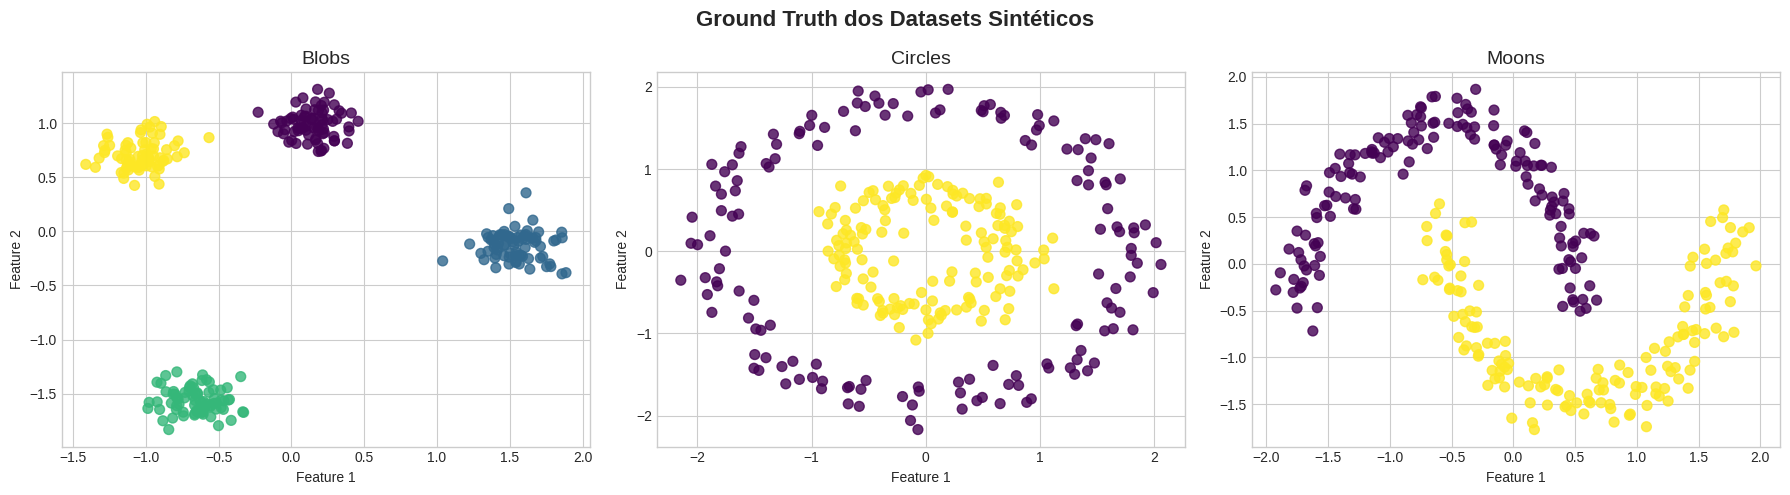

In [3]:
# Geração dos datasets
X_blobs, y_blobs = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)
X_circles, y_circles = make_circles(n_samples=300, noise=0.08, factor=0.4, random_state=42)
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=42)

# Normalização dos dados para que os algoritmos baseados em distância funcionem corretamente
X_blobs = StandardScaler().fit_transform(X_blobs)
X_circles = StandardScaler().fit_transform(X_circles)
X_moons = StandardScaler().fit_transform(X_moons)

# Dicionário para armazenar os datasets
datasets = {
    'Blobs': (X_blobs, y_blobs),
    'Circles': (X_circles, y_circles),
    'Moons': (X_moons, y_moons)
}

# Visualização dos datasets originais (ground truth)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ground Truth dos Datasets Sintéticos', fontsize=16, fontweight='bold')

for i, (name, (X, y)) in enumerate(datasets.items()):
    axes[i].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, alpha=0.8)
    axes[i].set_title(name, fontsize=14)
    axes[i].set_xlabel('Feature 1')
    axes[i].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

# Aplicação de Algoritmos de Clustering

Agora, aplicaremos três algoritmos de clustering populares a cada um dos datasets gerados. Os parâmetros de cada algoritmo foram ajustados para corresponder ao número esperado de clusters ou às características dos dados.

* **K-Means**: Define `n_clusters`.
* **Hierárquico Aglomerativo**: Define `n_clusters`.
* **DBSCAN**: Define `eps` (distância máxima entre dois pontos para serem considerados vizinhos) e `min_samples` (número mínimo de pontos para formar uma região densa).

In [4]:
# Configuração dos algoritmos
kmeans_params = {'random_state': 42}
agglomerative_params = {}
dbscan_params = {'eps': 0.4, 'min_samples': 4}

# Dicionário para armazenar os resultados
clustering_results = {}

for name, (X, y) in datasets.items():
    # Determine the number of clusters from the ground truth labels for K-Means and Agglomerative
    n_clusters = len(np.unique(y))
    kmeans_params['n_clusters'] = n_clusters
    agglomerative_params['n_clusters'] = n_clusters

    # K-Means
    kmeans = KMeans(**kmeans_params)
    kmeans_labels = kmeans.fit_predict(X)

    # Agglomerative Clustering
    agglomerative = AgglomerativeClustering(**agglomerative_params)
    agglomerative_labels = agglomerative.fit_predict(X)

    # DBSCAN
    dbscan = DBSCAN(**dbscan_params)
    dbscan_labels = dbscan.fit_predict(X)

    clustering_results[name] = {
        'K-Means': kmeans_labels,
        'Agglomerative': agglomerative_labels,
        'DBSCAN': dbscan_labels,
    }

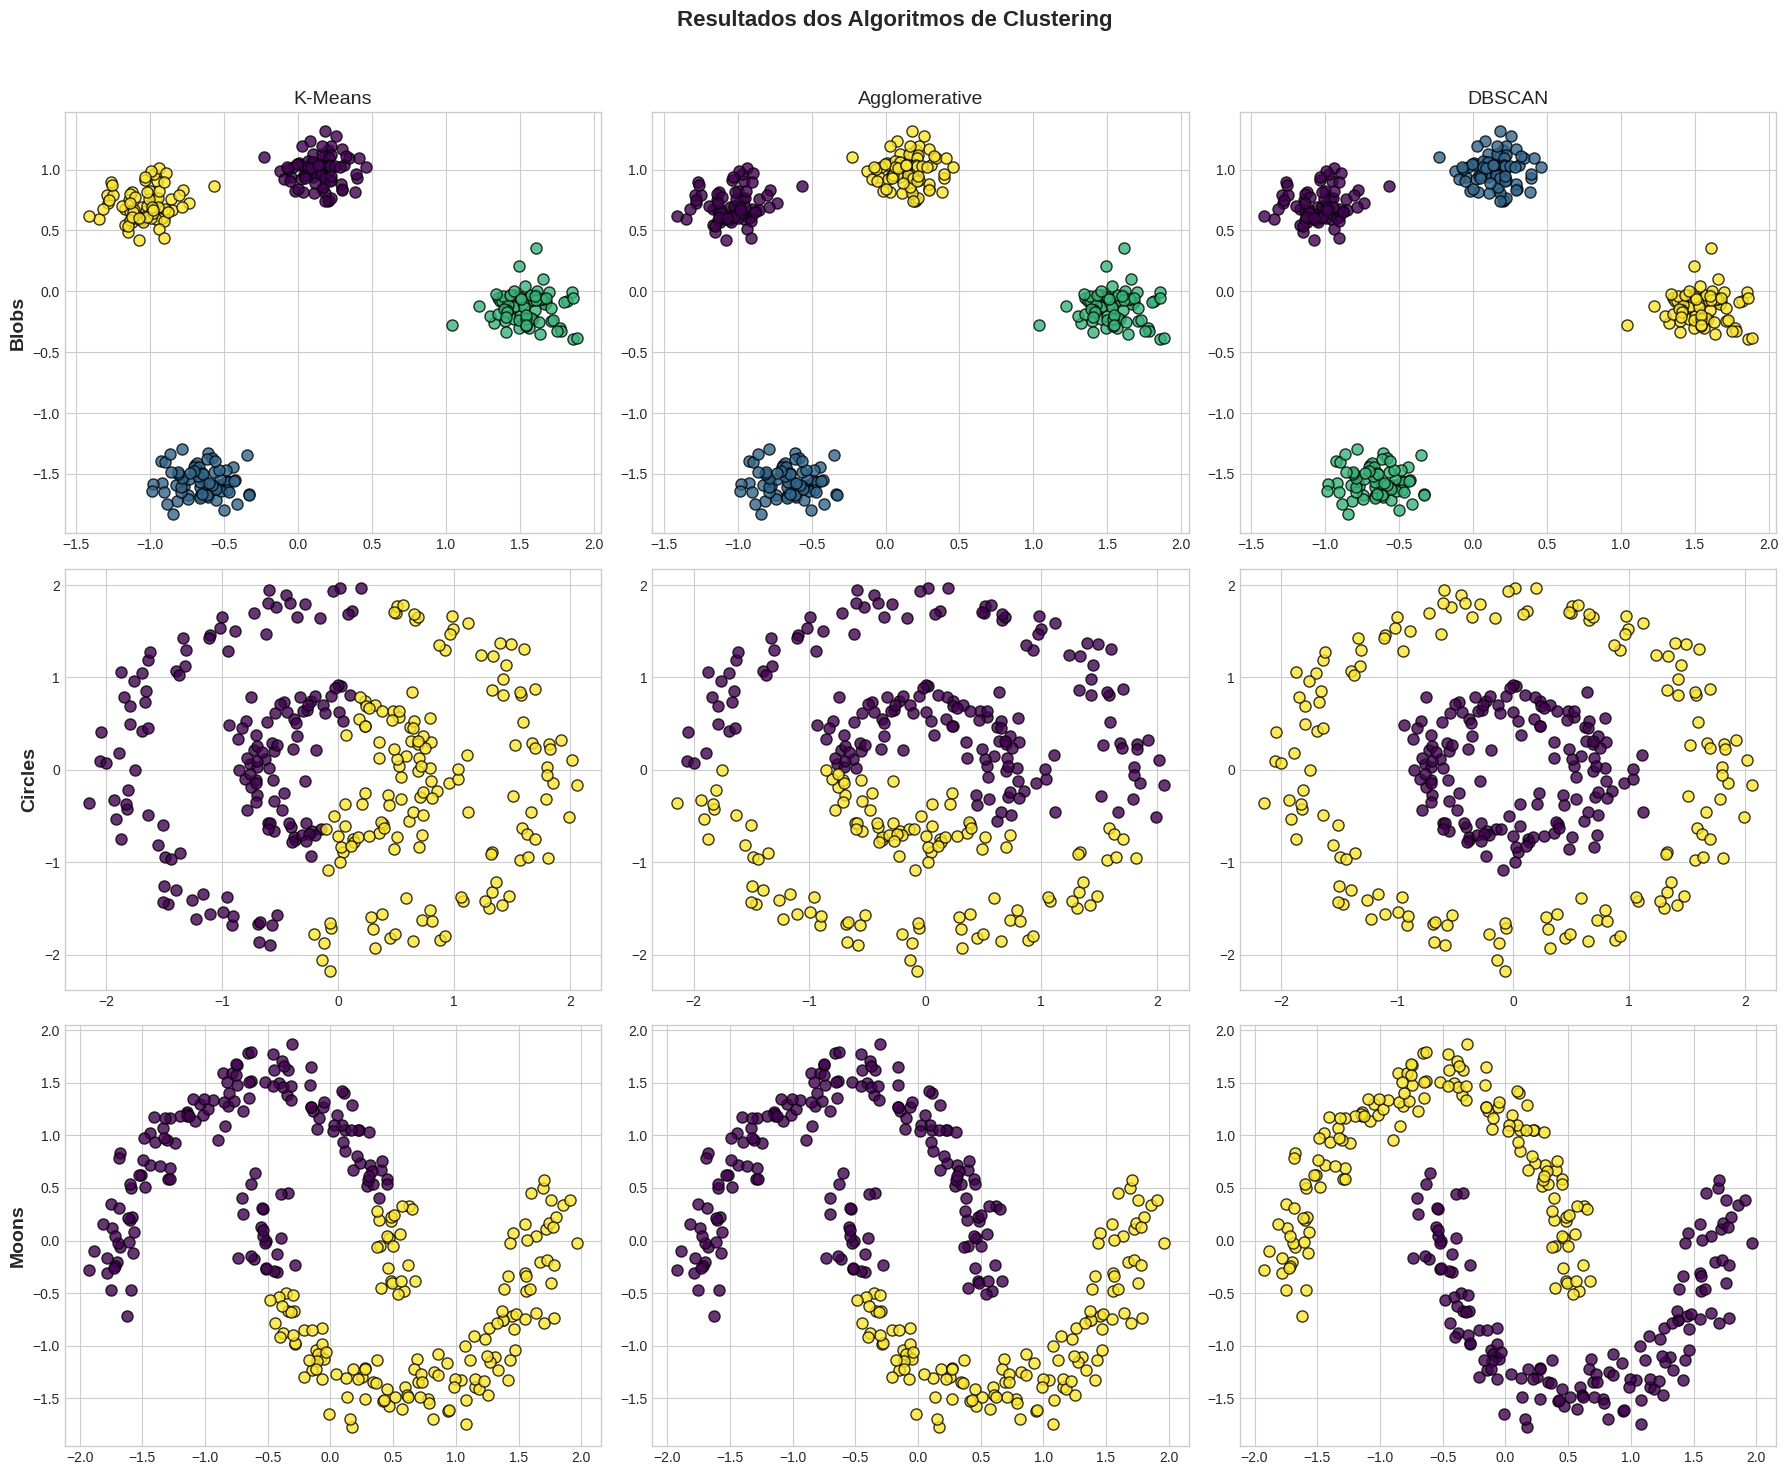

In [5]:
# Visualização dos resultados
fig, axes = plt.subplots(len(datasets), 3, figsize=(18, 15))
fig.suptitle('Resultados dos Algoritmos de Clustering', fontsize=16, fontweight='bold')

for i, (dataset_name, results) in enumerate(clustering_results.items()):
    X, _ = datasets[dataset_name]
    for j, (algo_name, labels) in enumerate(results.items()):
        ax = axes[i, j]
        # Pontos de ruído (-1) em preto para DBSCAN
        unique_labels = set(labels)
        colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))

        for k, col in zip(unique_labels, colors):
            if k == -1:
                col = [0, 0, 0, 1]  # Preto para ruído

            class_member_mask = (labels == k)
            xy = X[class_member_mask]
            ax.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
                    markeredgecolor='k', markersize=8, alpha=0.8)

        if i == 0:
            ax.set_title(algo_name, fontsize=14)
        if j == 0:
            ax.set_ylabel(dataset_name, fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Métricas de Avaliação Interna

Nesta seção, detalharemos e implementaremos as métricas internas para avaliar a qualidade dos clusters sem usar os rótulos verdadeiros.

## Silhouette Score

O Silhouette Score mede quão similar um objeto é ao seu próprio cluster (coesão) em comparação com outros clusters (separação). A pontuação varia de -1 a +1, onde um valor alto indica que o objeto está bem combinado ao seu próprio cluster e mal combinado aos clusters vizinhos.

### Formulação Matemática

Para um único ponto de dados $i$, o score de silhueta $s(i)$ é calculado como:

$$ s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}} $$

Onde:
- $a(i)$ é a distância média de $i$ para todos os outros pontos no mesmo cluster (coesão intra-cluster).
$$ a(i) = \frac{1}{|C_k| - 1} \sum_{j \in C_k, i \neq j} d(i, j) $$
em que $i \in C_k$.
- $b(i)$ é a menor distância média de $i$ para todos os pontos em qualquer outro cluster, do qual $i$ não é membro (separação inter-cluster).
$$ b(i) = \min_{m \neq k} \left( \frac{1}{|C_m|} \sum_{j \in C_m} d(i, j) \right) $$

O Silhouette Score para todo o dataset é a média de $s(i)$ sobre todos os pontos.

In [6]:
def silhouette_score(X, labels):
    """Calcula o Silhouette Score médio."""

    distances = cdist(X, X)
    unique_labels = np.unique(labels)
    unique_labels = unique_labels[unique_labels != -1]  # ignora outliers, se houver

    silhouette_values = []

    for i in range(len(X)):
        current_label = labels[i]

        # ignora pontos marcados como outlier
        if current_label == -1:
            continue

        # 1. a_i = distância média para pontos do mesmo cluster
        same_cluster = (labels == current_label)
        same_cluster[i] = False  # remove o próprio ponto

        if np.sum(same_cluster) == 0:
            a_i = 0
        else:
            a_i = np.mean(distances[i][same_cluster])

        # 2. b_i = menor distância média até outro cluster
        b_i = np.inf

        for other_label in unique_labels:
            if other_label == current_label:
                continue

            other_cluster = (labels == other_label)
            mean_distance = np.mean(distances[i][other_cluster])

            if mean_distance < b_i:
                b_i = mean_distance

        # 3. score de silhueta do ponto
        if max(a_i, b_i) == 0:
            s_i = 0
        else:
            s_i = (b_i - a_i) / max(a_i, b_i)

        silhouette_values.append(s_i)

    return np.mean(silhouette_values)

## Davies-Bouldin Index (DBI)

O Davies-Bouldin Index é definido como a similaridade média de cada cluster com seu cluster mais similar. A similaridade é uma medida que compara a distância intra-cluster com a distância inter-cluster. Valores mais baixos do DBI indicam um melhor clustering.

### Formulação Matemática

O índice é calculado como:

$$ DBI = \frac{1}{K} \sum_{k=1}^{K} \max_{m \neq k} \left( R_{km} \right) $$

Onde $K$ é o número de clusters e $R_{km}$ é a medida de similaridade entre o cluster $C_k$ e o cluster $C_m$:

$$ R_{km} = \frac{S_k + S_m}{D_{km}} $$

- $S_k$ é a dispersão média intra-cluster (distância média de cada ponto ao centroide do cluster $C_k$).
$$ S_k = \left( \frac{1}{|C_k|} \sum_{x \in C_k} \|x - \mu_k\|^2 \right)^{1/2} $$
em que $\mu_k$ é o centroide de $C_k$.
- $D_{km}$ é a distância entre os centroides dos clusters $C_k$ e $C_m$.
$$ D_{km} = \|\mu_k - \mu_m\|_2 $$

In [7]:
def davies_bouldin_score(X, labels):
    """Calcula o Davies-Bouldin Index."""

    # Remove rótulo -1, caso exista
    clusters = np.unique(labels)
    clusters = clusters[clusters != -1]
    n_clusters = len(clusters)

    # 1. Calcula o centróide de cada cluster
    centroids = []
    for c in clusters:
        points = X[labels == c]
        centroid = points.mean(axis=0)
        centroids.append(centroid)
    centroids = np.array(centroids)

    # 2. Calcula a dispersão de cada cluster
    dispersions = []
    for i, c in enumerate(clusters):
        points = X[labels == c]
        distances = np.linalg.norm(points - centroids[i], axis=1)
        dispersion = distances.mean()
        dispersions.append(dispersion)
    dispersions = np.array(dispersions)

    # 3. Para cada cluster i, acha o pior caso em relação aos outros clusters
    db_index = 0

    for i in range(n_clusters):
        worst_similarity = 0

        for j in range(n_clusters):
            if i == j:
                continue

            distance_between_centroids = np.linalg.norm(centroids[i] - centroids[j])
            similarity = (dispersions[i] + dispersions[j]) / distance_between_centroids

            if similarity > worst_similarity:
                worst_similarity = similarity

        db_index += worst_similarity

    # 4. Faz a média dos piores casos
    return db_index / n_clusters

## Dunn Index

O Dunn Index visa identificar clusters que são compactos e bem separados. Ele é definido como a razão entre a mínima distância inter-cluster e a máxima distância intra-cluster. Um valor mais alto do Dunn Index significa um melhor clustering.

### Formulação Matemática

O índice é dado por:

$$ D = \frac{\min_{1 \le k < m \le K} d(C_k, C_m)}{\max_{1 \le l \le K} \text{diam}(C_l)} $$

Onde:
- $d(C_k, C_m)$ é a distância entre os clusters $C_k$ e $C_m$ (distância inter-cluster), que pode ser definida de várias formas (e.g., distância entre centroides). Usaremos a distância mínima entre quaisquer dois pontos de clusters diferentes.
$$ d(C_k, C_m) = \min_{x \in C_k, y \in C_m} \|x - y\|_2 $$
- $\text{diam}(C_l)$ é o diâmetro do cluster $C_l$ (distância intra-cluster máxima), definido como a maior distância entre quaisquer dois pontos no mesmo cluster.
$$ \text{diam}(C_l) = \max_{x, y \in C_l} \|x - y\|_2 $$

In [8]:
def dunn_index(X, labels):
    """Calcula o Dunn Index para um conjunto de dados e seus rótulos."""

    unique_labels = np.unique(labels)
    pairwise_dists = squareform(pdist(X))

    # Máxima distância intra-cluster
    max_intra = 0
    for lab in unique_labels:
        idx = np.where(labels == lab)[0]
        if len(idx) > 1:
            d = np.max(pairwise_dists[np.ix_(idx, idx)])
            if d > max_intra:
                max_intra = d

    if max_intra == 0:
        return np.inf

    # Mínima distância inter-cluster
    min_inter = np.inf
    for i in range(len(unique_labels)):
        for j in range(i + 1, len(unique_labels)):
            idx_i = np.where(labels == unique_labels[i])[0]
            idx_j = np.where(labels == unique_labels[j])[0]
            d = np.min(pairwise_dists[np.ix_(idx_i, idx_j)])
            if d < min_inter:
                min_inter = d

    return min_inter / max_intra

# Análise Comparativa

Finalmente, vamos calcular cada métrica para cada combinação de dataset e algoritmo para avaliar e comparar os resultados.

* **Silhouette Score**: Quanto maior, melhor.
* **Davies-Bouldin Index**: Quanto menor, melhor.
* **Dunn Index**: Quanto maior, melhor.

In [9]:
evaluation_results = []

for dataset_name, results in clustering_results.items():
    X, _ = datasets[dataset_name]
    for algo_name, labels in results.items():
        silhouette = silhouette_score(X, labels)
        dbi = davies_bouldin_score(X, labels)
        dunn = dunn_index(X, labels)

        evaluation_results.append({
            'Dataset': dataset_name,
            'Algorithm': algo_name,
            'Silhouette Score': silhouette,
            'Davies-Bouldin Index': dbi,
            'Dunn Index': dunn
        })

In [10]:
# Criar DataFrame para visualização
results_df = pd.DataFrame(evaluation_results)

# Dicionário de formatação apenas para colunas numéricas
formatter = {
    'Silhouette Score': '{:.3f}',
    'Davies-Bouldin Index': '{:.3f}',
    'Dunn Index': '{:.3f}'
}

# Aplicar o estilo e a formatação seletiva
results_df_styled = results_df.style.background_gradient(
    cmap='viridis', subset=['Silhouette Score', 'Dunn Index']
).background_gradient(
    cmap='viridis_r', subset=['Davies-Bouldin Index']
).format(formatter)

display(results_df_styled)

,Dataset,Algorithm,Silhouette Score,Davies-Bouldin Index,Dunn Index
0,Blobs,K-Means,0.839,0.224,0.466
1,Blobs,Agglomerative,0.839,0.224,0.466
2,Blobs,DBSCAN,0.839,0.224,0.466
3,Circles,K-Means,0.320,1.238,0.010
4,Circles,Agglomerative,0.313,1.237,0.023
5,Circles,DBSCAN,0.148,95.380,0.102
6,Moons,K-Means,0.494,0.806,0.043
7,Moons,Agglomerative,0.452,0.864,0.074
8,Moons,DBSCAN,0.380,1.025,0.149


## Exercícios

### Exercício 1

Altere os parâmetros iniciais dos algoritmos **K-Means**, **Hierárquico Aglomerativo** e **DBSCAN** (por exemplo, variando o número de clusters em `n_clusters` e os valores de `eps` e `min_samples`), execute os modelos nos datasets utilizados anteriormente, avalie os resultados com as métricas **Silhouette Score**, **Davies-Bouldin Index** e **Índice de Dunn**, e analise como as mudanças nos parâmetros influenciam a qualidade dos agrupamentos e o comportamento de cada métrica.

In [11]:
# Configuração dos algoritmos
kmeans_params = {'n_clusters': 2, 'random_state': 42}
agglomerative_params = {'n_clusters': 6}
dbscan_params = {'eps': 0.5, 'min_samples': 6}

# Dicionário para armazenar os resultados
clustering_results = {}

for name, (X, y) in datasets.items():
    # K-Means
    kmeans = KMeans(**kmeans_params)
    kmeans_labels = kmeans.fit_predict(X)

    # Agglomerative Clustering
    agglomerative = AgglomerativeClustering(**agglomerative_params)
    agglomerative_labels = agglomerative.fit_predict(X)

    # DBSCAN
    dbscan = DBSCAN(**dbscan_params)
    dbscan_labels = dbscan.fit_predict(X)

    clustering_results[name] = {
        'K-Means': kmeans_labels,
        'Agglomerative': agglomerative_labels,
        'DBSCAN': dbscan_labels,
    }

/tmp/ipykernel_7038/835326022.py:43: RuntimeWarning: invalid value encountered in scalar divide
  s_i = (b_i - a_i) / max(a_i, b_i)
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/style.py:3811: RuntimeWarning: invalid value encountered in scalar multiply
  norm = _matplotlib.colors.Normalize(smin - (rng * low), smax + (rng * high))


,Dataset,Algorithm,Silhouette Score,Davies-Bouldin Index,Dunn Index
0,Blobs,K-Means,0.570,0.555,0.505
1,Blobs,Agglomerative,0.579,0.810,0.043
2,Blobs,DBSCAN,0.764,0.349,0.655
3,Circles,K-Means,0.320,1.238,0.010
4,Circles,Agglomerative,0.333,0.822,0.033
5,Circles,DBSCAN,nan,0.000,inf
6,Moons,K-Means,0.494,0.806,0.043
7,Moons,Agglomerative,0.437,0.734,0.039
8,Moons,DBSCAN,nan,0.000,inf


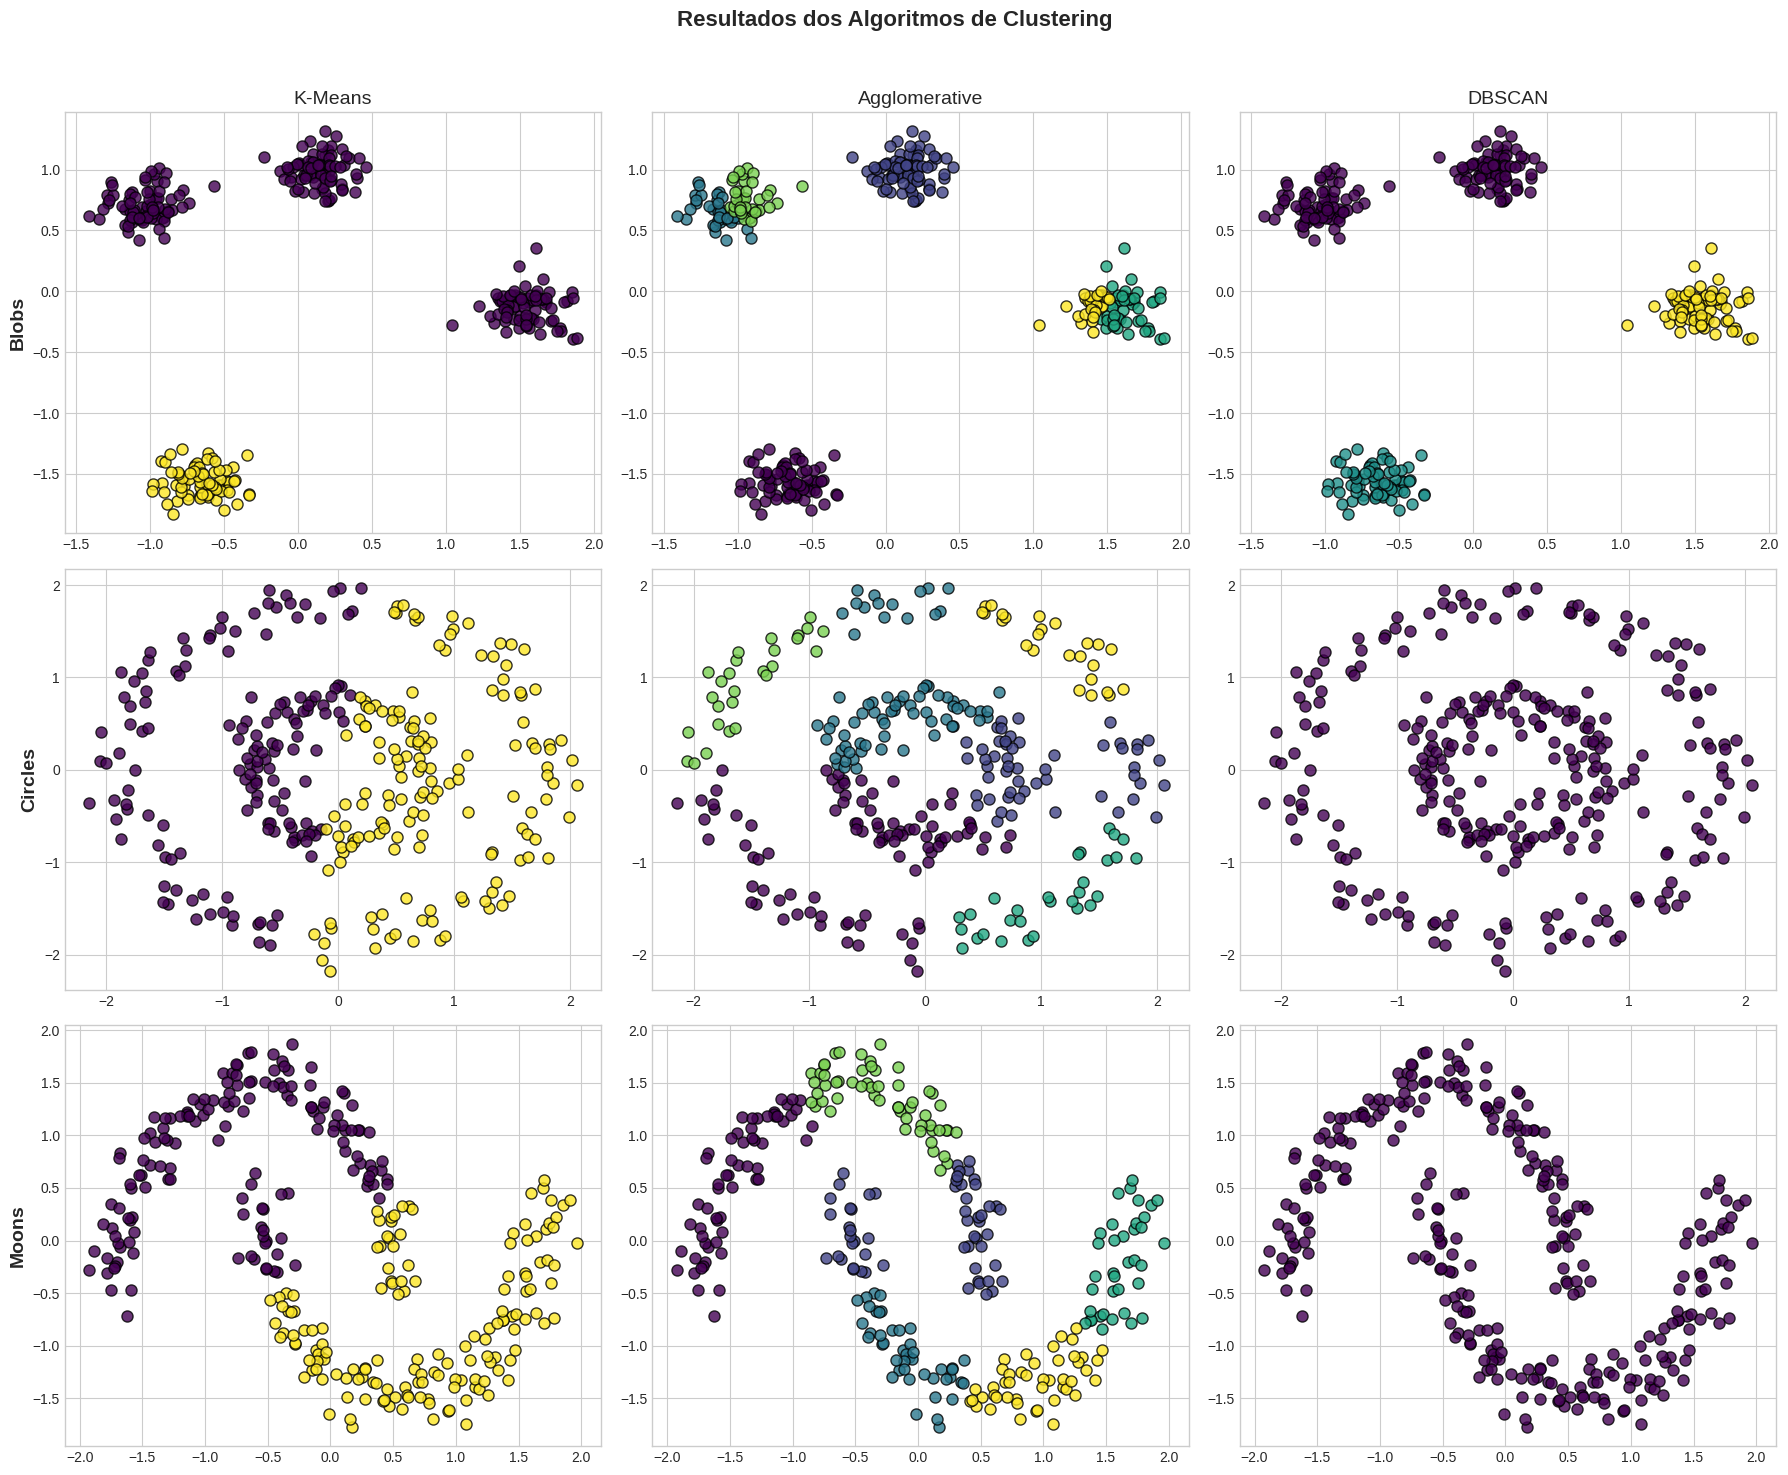

In [12]:
evaluation_results = []

for dataset_name, results in clustering_results.items():
    X, _ = datasets[dataset_name]
    for algo_name, labels in results.items():
        silhouette = silhouette_score(X, labels)
        dbi = davies_bouldin_score(X, labels)
        dunn = dunn_index(X, labels)

        evaluation_results.append({
            'Dataset': dataset_name,
            'Algorithm': algo_name,
            'Silhouette Score': silhouette,
            'Davies-Bouldin Index': dbi,
            'Dunn Index': dunn
        })
# Criar DataFrame para visualização
results_df = pd.DataFrame(evaluation_results)

# Dicionário de formatação apenas para colunas numéricas
formatter = {
    'Silhouette Score': '{:.3f}',
    'Davies-Bouldin Index': '{:.3f}',
    'Dunn Index': '{:.3f}'
}

# Aplicar o estilo e a formatação seletiva
results_df_styled = results_df.style.background_gradient(
    cmap='viridis', subset=['Silhouette Score', 'Dunn Index']
).background_gradient(
    cmap='viridis_r', subset=['Davies-Bouldin Index']
).format(formatter)

display(results_df_styled)


# Visualização dos resultados
fig, axes = plt.subplots(len(datasets), 3, figsize=(18, 15))
fig.suptitle('Resultados dos Algoritmos de Clustering', fontsize=16, fontweight='bold')

for i, (dataset_name, results) in enumerate(clustering_results.items()):
    X, _ = datasets[dataset_name]
    for j, (algo_name, labels) in enumerate(results.items()):
        ax = axes[i, j]
        # Pontos de ruído (-1) em preto para DBSCAN
        unique_labels = set(labels)
        colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))

        for k, col in zip(unique_labels, colors):
            if k == -1:
                col = [0, 0, 0, 1]  # Preto para ruído

            class_member_mask = (labels == k)
            xy = X[class_member_mask]
            ax.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
                    markeredgecolor='k', markersize=8, alpha=0.8)

        if i == 0:
            ax.set_title(algo_name, fontsize=14)
        if j == 0:
            ax.set_ylabel(dataset_name, fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Analise das novas métricas apos a modificação dos parâmetros
Com os novos parâmetros `(KMeans=2, Agglomerative=6, DBSCAN eps=0.5)`, os resultados variaram conforme o dataset.
## Blobs:
K-Means teve desempenho inferior por reduzir de 4 para 2 clusters.
O Agglomerative apresentou queda no Silhouette e no Dunn Index, provavelmente devido à baixa dispersão e maior sobreposição entre clusters, causada pelo uso de 6 grupos em uma estrutura originalmente mais simples.
Já o DBSCAN obteve o melhor resultado, adaptando-se bem à densidade dos dados.

## Circles:
K-Means falhou por não lidar com formas não convexas, e o Agglomerative também não capturou corretamente a estrutura circular.
Ainda assim, as pontuações de ambos permaneceram praticamente iguais à análise anterior, o que é esperado dada a natureza do Silhouette Score que já não é bom para avaliar formas não convexas, o mesmo a respeito de dunn index já que em circles os cluesters basicamente se sobrepoem.

O DBSCAN retornou valores inválidos (NaN, 0, inf) porque, com os novos parâmetros, formou-se apenas um único cluster, inviabilizando o cálculo do silhouette e do dunn, além de levar à minimização de DBI.

## Moons:
O comportamento foi semelhante ao Circles.
K-Means e Agglomerative continuaram apresentando baixa qualidade, com valores de pontuação permanecendo praticamente os mesmos aos anteriores a modificação de parametros.
O DBSCAN repetiu o problema anterior, e a explicação segue a mesma: formação de um único cluster, como já mencionado no caso de Circles.

### Conclusão:
 Os parâmetros do DBSCAN foram inadequados para formas não convexas, enquanto K-Means e Agglomerative mantiveram desempenho limitado pela própria natureza dos dados.

### Exercício 2

Aplique os algoritmos de agrupamento **K-Means**, **Hierárquico Aglomerativo** e **DBSCAN** ao conjunto de dados **Iris**, avalie os resultados utilizando as métricas **Silhouette Score**, **Davies-Bouldin Index** e **Índice de Dunn**, compare o desempenho dos métodos com base nessas métricas e discuta qual apresentou melhores resultados considerando as características dos dados e o comportamento de cada algoritmo.

,Dataset,Algorithm,Silhouette Score,Davies-Bouldin Index,Dunn Index
0,Iris,K-Means,0.480,0.789,0.053
1,Iris,Agglomerative,0.447,0.803,0.098
2,Iris,DBSCAN,0.656,0.494,0.048


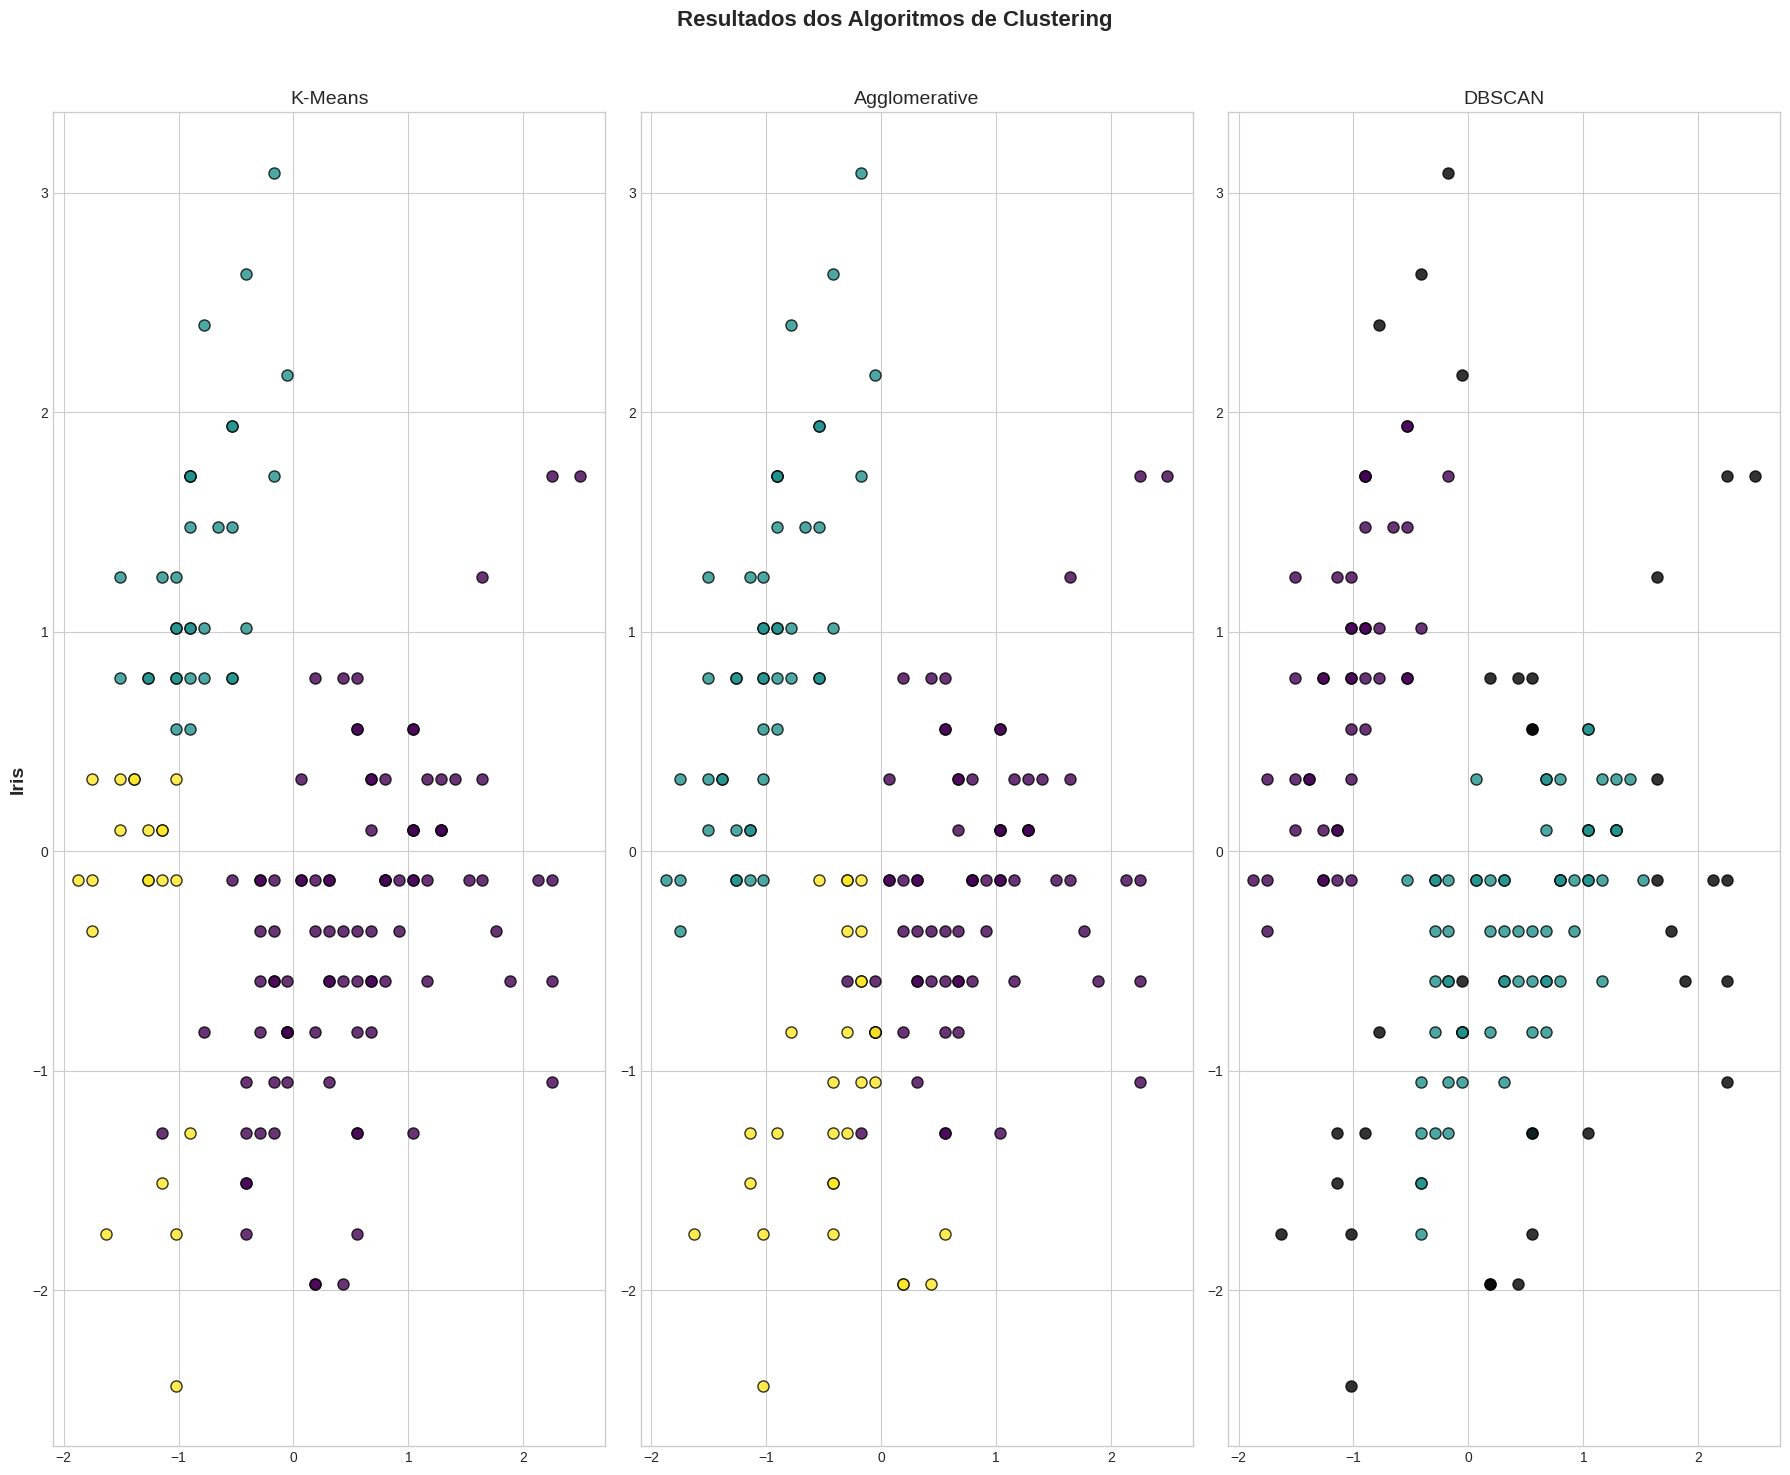

In [14]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

X_iris = StandardScaler().fit_transform(X_iris)

datasets = {'Iris': (X_iris, y_iris)}

clustering_results = {}

for dataset_name, (X, _) in datasets.items():
    clustering_results[dataset_name] = {}

    clustering_results[dataset_name]['K-Means'] = KMeans(n_clusters=3, random_state=42).fit_predict(X)
    clustering_results[dataset_name]['Agglomerative'] = AgglomerativeClustering(n_clusters=3).fit_predict(X)
    clustering_results[dataset_name]['DBSCAN'] = DBSCAN(eps=0.5, min_samples=5).fit_predict(X)

evaluation_results = []

for dataset_name, results in clustering_results.items():
    X, _ = datasets[dataset_name]
    for algo_name, labels in results.items():
        silhouette = silhouette_score(X, labels)
        dbi = davies_bouldin_score(X, labels)
        dunn = dunn_index(X, labels)

        evaluation_results.append({
            'Dataset': dataset_name,
            'Algorithm': algo_name,
            'Silhouette Score': silhouette,
            'Davies-Bouldin Index': dbi,
            'Dunn Index': dunn
        })
# Criar DataFrame para visualização
results_df = pd.DataFrame(evaluation_results)

# Dicionário de formatação apenas para colunas numéricas
formatter = {
    'Silhouette Score': '{:.3f}',
    'Davies-Bouldin Index': '{:.3f}',
    'Dunn Index': '{:.3f}'
}

# Aplicar o estilo e a formatação seletiva
results_df_styled = results_df.style.background_gradient(
    cmap='viridis', subset=['Silhouette Score', 'Dunn Index']
).background_gradient(
    cmap='viridis_r', subset=['Davies-Bouldin Index']
).format(formatter)

display(results_df_styled)



fig, axes = plt.subplots(len(datasets), 3, figsize=(18, 15))
fig.suptitle('Resultados dos Algoritmos de Clustering', fontsize=16, fontweight='bold')

for i, (dataset_name, results) in enumerate(clustering_results.items()):
    X, _ = datasets[dataset_name]
    for j, (algo_name, labels) in enumerate(results.items()):

        ax = axes[j]
        # Pontos de ruído (-1) em preto para DBSCAN
        unique_labels = set(labels)
        colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))

        for k, col in zip(unique_labels, colors):
            if k == -1:
                col = [0, 0, 0, 1]  # Preto para ruído

            class_member_mask = (labels == k)
            xy = X[class_member_mask]
            ax.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
                    markeredgecolor='k', markersize=8, alpha=0.8)

        if i == 0:
            ax.set_title(algo_name, fontsize=14)
        if j == 0:
            ax.set_ylabel(dataset_name, fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Analise das métricas no dataset íris:
## `DBSCAN (Silhouette score = 0,656 , DBI = 0,494, Dunn = 0,048)`
o DBSCAN foi oque obteve o melhor silhouette score e o menor DBI, indicando que os clusters encontrados dados os parametros de eps e min points são relativamente bem definidos.

## `Aglomerativo (Silhouette score = 0,447 , DBI = 0,803, Dunn = 0,098)`
O hierarquico aglomerativo apresenta o menor silhouette score e maior DBI, o que sugere um desempenho iferior aos demais metodos de clustering. Entretanto, o mesmo possui o maior valor de Dunn index o que indica uma melhor separação entre os clusters, embora o valor continue incrivelmente baixo dado a natureza caotica do dataset.

## `K-Means (Silhouette score = 0,480 , DBI = 0,789, Dunn = 0,053)`
K-means teve um desempenho que considero bom, mesmo sendo consideravelmente pior do que o do DBSCAN, isso é estava dentro de minhas previsões dado a natureza do k-means de desempenhar melhor com clusters esfericos.

### Conclusão
Minha analise mostrou que mesmo que dos 3 algoritmos de clusterização aquele que desempenhou melhor em separar os grupos, foi o DBSCAN que lidou com ruidos e conseguiu criar clusters bem definidos, coesos e dispersos. K-means e Hierarquico tambem performaram de maneira razoável, entretanto ambos apresentaram resultados inferiores.